# 05b — model_capacity

**Task:** Predict expected seats per section for a given course × term (regressor)

**Target:** `target_capacity` (mean historical capacity per section)

**Models tested:**
1. Baseline — always predict mean training capacity
2. Linear Regression
3. Ridge Regression
4. Random Forest
5. Gradient Boosting

**Selection metric:** MAE on test set (lower = better). Brier score not applicable for regressors.
If MAE tied: RMSE tiebreaker. If still tied: alphabetical.

**Figures saved to:** `notebooks/figures/05b/`

## 0. Setup

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH   = Path('../data/processed')
MODELS_PATH = Path('../models')
FIG_PATH    = Path('figures/05b_model_capacity')
FIG_PATH.mkdir(parents=True, exist_ok=True)

assert (DATA_PATH / '04_train.csv').exists(),        'run 04 first'
assert (MODELS_PATH / 'feature_sets.json').exists(), 'run 04 first'
print('ready')

ready


## 1. Load data and define X, y

In [2]:
train   = pd.read_csv(DATA_PATH / '04_train.csv')
test    = pd.read_csv(DATA_PATH / '04_test.csv')
train_s = pd.read_csv(DATA_PATH / '04_train_scaled.csv')
test_s  = pd.read_csv(DATA_PATH / '04_test_scaled.csv')

with open(MODELS_PATH / 'feature_sets.json') as f:
    FEATURES = json.load(f)['model_capacity']

TARGET = 'target_capacity'

# exclude cold start rows — no historical capacity data, no target to learn from
train_c  = train[train[TARGET].notna()].copy()
test_c   = test[test[TARGET].notna()].copy()
train_cs = train_s[train_s[TARGET].notna()].copy()
test_cs  = test_s[test_s[TARGET].notna()].copy()

X_train   = train_c[FEATURES];  y_train = train_c[TARGET]
X_test    = test_c[FEATURES];   y_test  = test_c[TARGET]
X_train_s = train_cs[FEATURES]
X_test_s  = test_cs[FEATURES]

print(f'X_train: {X_train.shape}  target mean: {y_train.mean():.1f} seats')
print(f'X_test:  {X_test.shape}   target mean: {y_test.mean():.1f} seats')
print(f'cold start excluded — train: {train[TARGET].isna().sum():,}  test: {test[TARGET].isna().sum():,}')

X_train: (19777, 26)  target mean: 52.1 seats
X_test:  (4306, 26)   target mean: 49.9 seats
cold start excluded — train: 27,983  test: 5,246


## 2. Helper functions

In [3]:
def evaluate_regressor(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'model': name, 'mae': round(mae, 3),
            'rmse': round(rmse, 3), 'r2': round(r2, 4)}

def plot_pred_vs_actual(ax, y_true, y_pred, title, color):
    ax.scatter(y_true, y_pred, alpha=0.3, s=8, color=color)
    lim = max(y_true.max(), np.array(y_pred).max())
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='perfect')
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_xlabel('Actual capacity')
    ax.set_ylabel('Predicted capacity')
    ax.set_title(f'{title}  (MAE={mae:.1f})', fontsize=10, fontweight='500')
    ax.legend(fontsize=8)

results = []
print('helpers defined')

helpers defined


## 3. Baseline — always predict mean training capacity

In [4]:
mean_cap = y_train.mean()
y_base   = np.full(len(y_test), mean_cap)

base_metrics = evaluate_regressor('Baseline', y_test, y_base)
results.append(base_metrics)

print(f'Baseline always predicts: {mean_cap:.1f} seats')
print(f'Baseline MAE:  {base_metrics["mae"]:.2f} seats')
print(f'Baseline RMSE: {base_metrics["rmse"]:.2f} seats')
print(f'Baseline R²:   {base_metrics["r2"]}')
print()
print('Every model must beat this MAE.')

Baseline always predicts: 52.1 seats
Baseline MAE:  40.76 seats
Baseline RMSE: 59.63 seats
Baseline R²:   -0.0014

Every model must beat this MAE.


## 4. Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_lr = lr.predict(X_test_s)

lr_metrics = evaluate_regressor('Linear Regression', y_test, y_lr)
results.append(lr_metrics)
print(lr_metrics)

{'model': 'Linear Regression', 'mae': np.float64(25.452), 'rmse': np.float64(41.942), 'r2': 0.5047}


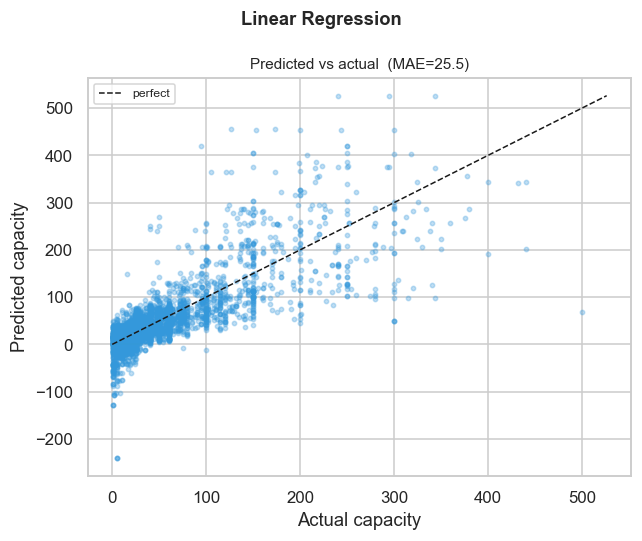

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Linear Regression', fontsize=12, fontweight='bold')
plot_pred_vs_actual(ax, y_test, y_lr, 'Predicted vs actual', '#3498db')
plt.tight_layout()
plt.savefig(FIG_PATH / 'lr.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ridge Regression

In [7]:
# RidgeCV automatically finds the best alpha via cross-validation
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 500.0], cv=5)
ridge.fit(X_train_s, y_train)
y_ridge = ridge.predict(X_test_s)

ridge_metrics = evaluate_regressor('Ridge Regression', y_test, y_ridge)
results.append(ridge_metrics)
print(ridge_metrics)
print(f'Best alpha: {ridge.alpha_}')

{'model': 'Ridge Regression', 'mae': np.float64(25.255), 'rmse': np.float64(41.773), 'r2': 0.5086}
Best alpha: 100.0


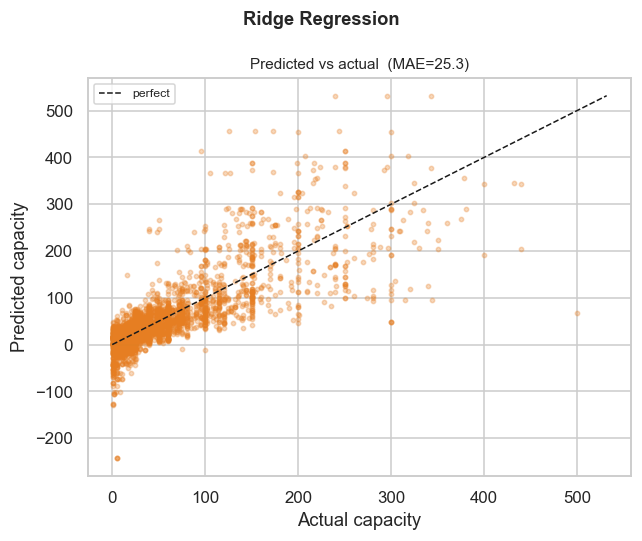

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Ridge Regression', fontsize=12, fontweight='bold')
plot_pred_vs_actual(ax, y_test, y_ridge, 'Predicted vs actual', '#e67e22')
plt.tight_layout()
plt.savefig(FIG_PATH / 'ridge.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Random Forest

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_rf = rf.predict(X_test)

rf_metrics = evaluate_regressor('Random Forest', y_test, y_rf)
results.append(rf_metrics)
print(rf_metrics)

{'model': 'Random Forest', 'mae': np.float64(12.034), 'rmse': np.float64(23.192), 'r2': 0.8485}


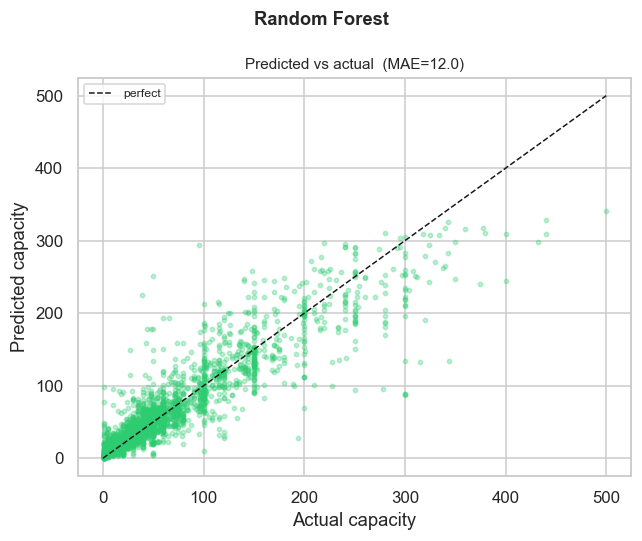

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Random Forest', fontsize=12, fontweight='bold')
plot_pred_vs_actual(ax, y_test, y_rf, 'Predicted vs actual', '#2ecc71')
plt.tight_layout()
plt.savefig(FIG_PATH / 'rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Gradient Boosting

In [11]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_gb = gb.predict(X_test)

gb_metrics = evaluate_regressor('Gradient Boosting', y_test, y_gb)
results.append(gb_metrics)
print(gb_metrics)

{'model': 'Gradient Boosting', 'mae': np.float64(12.954), 'rmse': np.float64(23.865), 'r2': 0.8396}


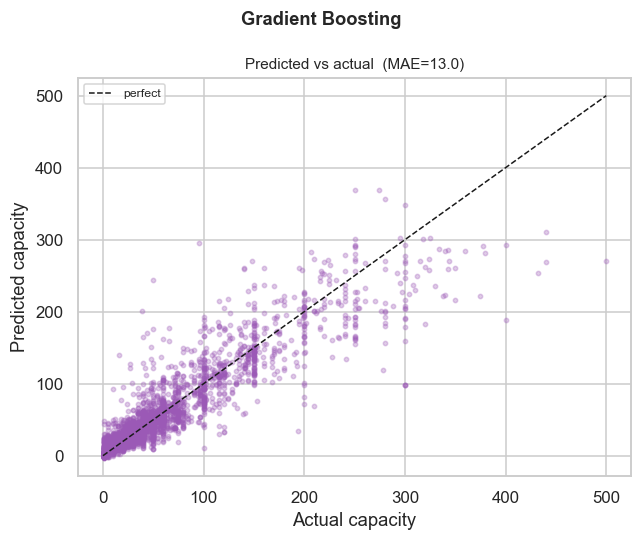

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle('Gradient Boosting', fontsize=12, fontweight='bold')
plot_pred_vs_actual(ax, y_test, y_gb, 'Predicted vs actual', '#9b59b6')
plt.tight_layout()
plt.savefig(FIG_PATH / 'gb.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparison

In [13]:
results_df = pd.DataFrame(results).set_index('model')
print('=== ALL MODELS ===')
results_df

=== ALL MODELS ===


,mae,rmse,r2
model,,,
Baseline,40.764,59.634,-0.0014
Linear Regression,25.452,41.942,0.5047
Ridge Regression,25.255,41.773,0.5086
Random Forest,12.034,23.192,0.8485
Gradient Boosting,12.954,23.865,0.8396


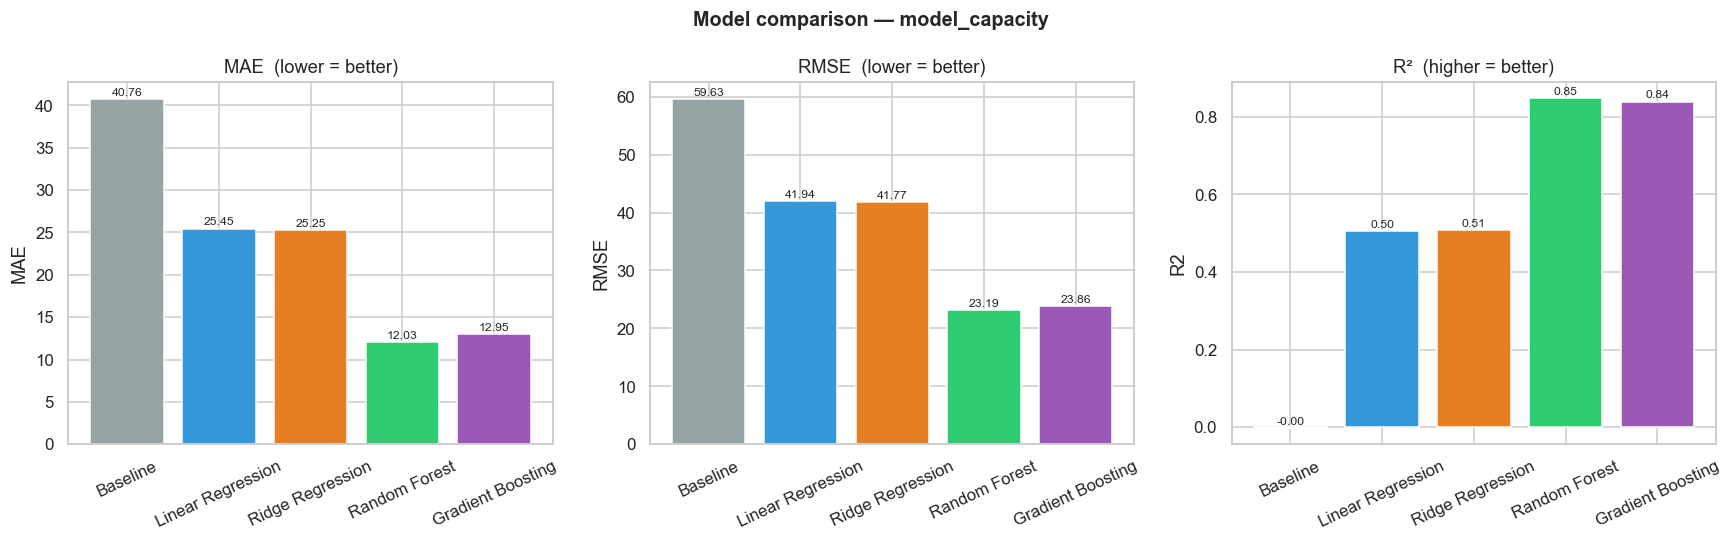

In [14]:
results_df.to_csv(DATA_PATH / '05b_results.csv')

colors  = ['#95a5a6','#3498db','#e67e22','#2ecc71','#9b59b6']
models  = results_df.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model comparison — model_capacity', fontsize=13, fontweight='bold')

for ax, metric, label, better in [
    (axes[0], 'mae',  'MAE  (lower = better)',  'min'),
    (axes[1], 'rmse', 'RMSE  (lower = better)', 'min'),
    (axes[2], 'r2',   'R²  (higher = better)',  'max'),
]:
    ax.bar(models, results_df[metric], color=colors, edgecolor='white')
    ax.set_title(label)
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=25)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + results_df[metric].max()*0.01,
                f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_PATH / 'comparison.png', dpi=150, bbox_inches='tight')
plt.show()

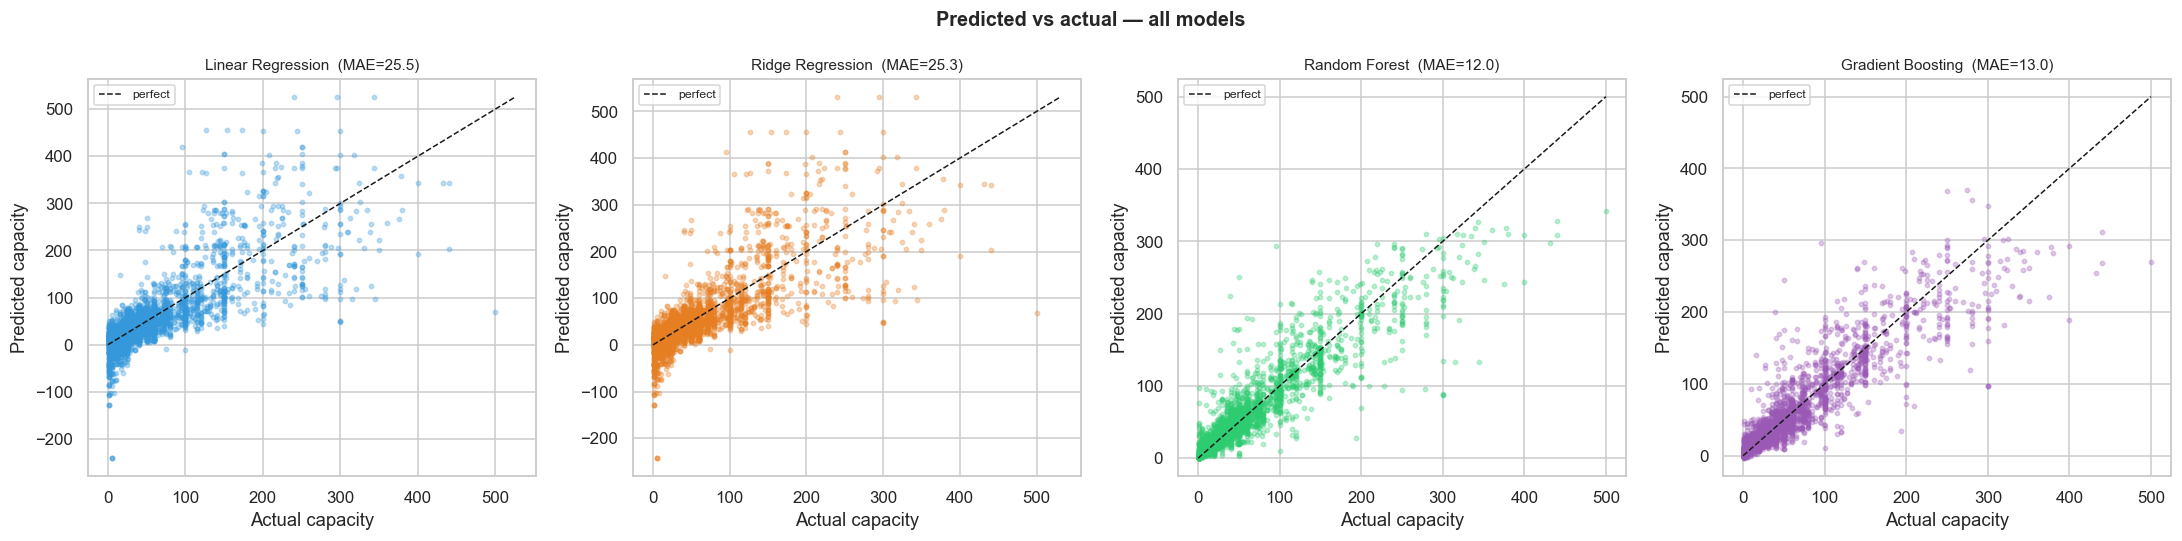

In [15]:
# predicted vs actual for all 4 models side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Predicted vs actual — all models', fontsize=13, fontweight='bold')

for ax, (name, y_pred, color) in zip(axes, [
    ('Linear Regression', y_lr,    '#3498db'),
    ('Ridge Regression',  y_ridge, '#e67e22'),
    ('Random Forest',     y_rf,    '#2ecc71'),
    ('Gradient Boosting', y_gb,    '#9b59b6'),
]):
    plot_pred_vs_actual(ax, y_test, y_pred, name, color)

plt.tight_layout()
plt.savefig(FIG_PATH / 'pred_vs_actual_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Winner — feature importance + residuals + save

In [16]:
# step 1: find all models tied at lowest MAE
min_mae    = results_df.drop('Baseline')['mae'].min()
top_models = results_df.drop('Baseline')[results_df.drop('Baseline')['mae'] == min_mae].index.tolist()
print(f'Min MAE: {min_mae}')
print(f'Models at min MAE: {top_models}')

# step 2: RMSE tiebreaker
rmse_map = results_df.loc[top_models, 'rmse'].to_dict()
min_rmse  = min(rmse_map.values())
rmse_winners = sorted([n for n, v in rmse_map.items() if v == min_rmse])
best_row = rmse_winners[0]  # alphabetical if still tied

model_map = {
    'Linear Regression': (lr,    X_test_s, y_lr),
    'Ridge Regression':  (ridge, X_test_s, y_ridge),
    'Random Forest':     (rf,    X_test,   y_rf),
    'Gradient Boosting': (gb,    X_test,   y_gb),
}
best_model, best_X_test, best_y_pred = model_map[best_row]

print(f'\nWinner: {best_row}')
print(f'  MAE:  {results_df.loc[best_row, "mae"]}')
print(f'  RMSE: {results_df.loc[best_row, "rmse"]}')
print(f'  R²:   {results_df.loc[best_row, "r2"]}')

Min MAE: 12.034
Models at min MAE: ['Random Forest']

Winner: Random Forest
  MAE:  12.034
  RMSE: 23.192
  R²:   0.8485


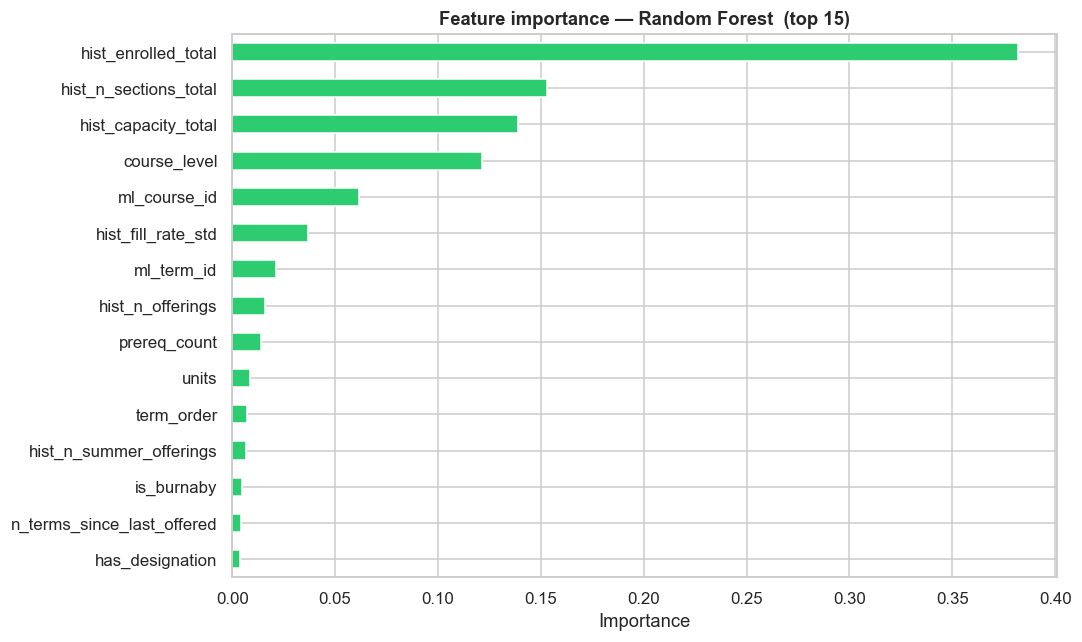

In [17]:
# feature importance — tree models only
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES)
    top15 = importances.nlargest(15).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    top15.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
    ax.set_title(f'Feature importance — {best_row}  (top 15)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'winner_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # linear model — show coefficients instead
    coefs = pd.Series(best_model.coef_, index=FEATURES)
    top15 = coefs.abs().nlargest(15).index
    coefs[top15].sort_values().plot(kind='barh', color='#3498db',
                                     edgecolor='white',
                                     figsize=(10, 6),
                                     title=f'Coefficients — {best_row}  (top 15 by magnitude)')
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'winner_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

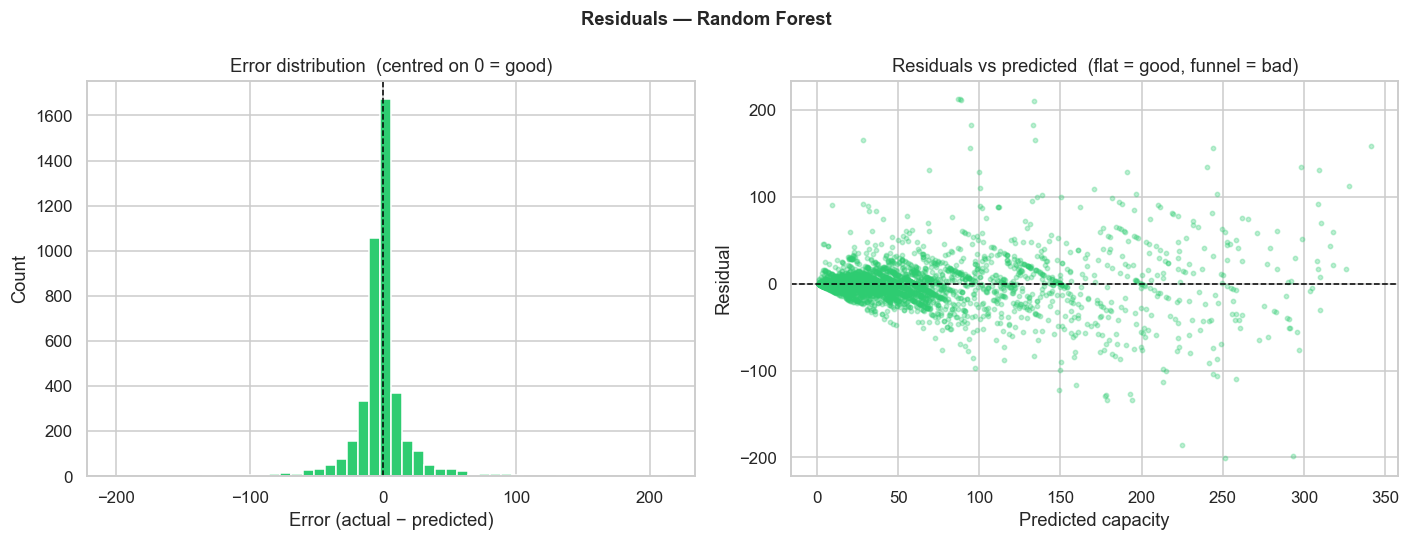

Mean error:   -0.73  (should be ~0)
Std of error: 23.18 seats
Max overpredict: -201.1 seats
Max underpredict:213.0 seats


In [18]:
# residual plot — distribution of errors
residuals = y_test.values - np.array(best_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Residuals — {best_row}', fontsize=12, fontweight='bold')

# histogram of errors
axes[0].hist(residuals, bins=50, color='#2ecc71', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', lw=1)
axes[0].set_xlabel('Error (actual − predicted)')
axes[0].set_ylabel('Count')
axes[0].set_title('Error distribution  (centred on 0 = good)')

# residuals vs predicted
axes[1].scatter(best_y_pred, residuals, alpha=0.3, s=8, color='#2ecc71')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_xlabel('Predicted capacity')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs predicted  (flat = good, funnel = bad)')

plt.tight_layout()
plt.savefig(FIG_PATH / 'winner_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean error:   {residuals.mean():.2f}  (should be ~0)')
print(f'Std of error: {residuals.std():.2f} seats')
print(f'Max overpredict: {residuals.min():.1f} seats')
print(f'Max underpredict:{residuals.max():.1f} seats')

In [19]:
joblib.dump(best_model, MODELS_PATH / 'model_capacity.pkl')
print(f'saved: models/model_capacity.pkl  ({best_row})')

saved: models/model_capacity.pkl  (Random Forest)
